### Purpose of the Code

This program demonstrates Mean Shift clustering, an unsupervised machine learning algorithm that automatically finds clusters in a set of 2D data points without specifying the number of clusters in advance.

In [1]:
import numpy as np  # For numerical computations and handling arrays
import pandas as pd  # Commonly used for data manipulation (not used here)
import matplotlib.pyplot as plt  # For plotting
from matplotlib.colors import Normalize  # Used to scale colors for plotting

# Import the MeanShift clustering model from scikit-learn
from sklearn.cluster import MeanShift


In [7]:
# Define a small dataset with 4 points in 2D space
X = np.array([[2,3], [6,1], [1,2], [3,0]])

# Print the dataset to verify it loaded correctly
print('Data:\n', X, '\n')


Data:
 [[2 3]
 [6 1]
 [1 2]
 [3 0]] 



In [8]:
# Construct (initialize) the MeanShift model
# Unlike K-Means, we don't specify the number of clusters
ms = MeanShift()

# Fit (train) the MeanShift model on our dataset X
# The algorithm will automatically estimate cluster centers and labels
ms.fit(X)


MeanShift()

In [9]:
# Extract cluster labels for each point
labels = ms.labels_


In [10]:
# Find unique cluster labels (each represents one cluster)
labels_unique = np.unique(labels)

# Count how many unique clusters were found
n_clusters_ = len(labels_unique)
print("number of estimated clusters: %d\n" % n_clusters_)


number of estimated clusters: 4



Mean Shift automatically determines how many clusters exist based on density peaks in the data — not a user-specified number like in K-Means.

In [13]:

# Get coordinates of the cluster centers found by Mean Shift
cluster_centers = ms.cluster_centers_

# Print the cluster centers
centers = ms.cluster_centers_
print('Centroids:\n', centers, '\n')


Centroids:
 [[6. 1.]
 [3. 0.]
 [2. 3.]
 [1. 2.]] 



In [14]:
# Define a test point to classify
test_point = np.array([[3,1]])


Text(0, 0.5, 'X2')

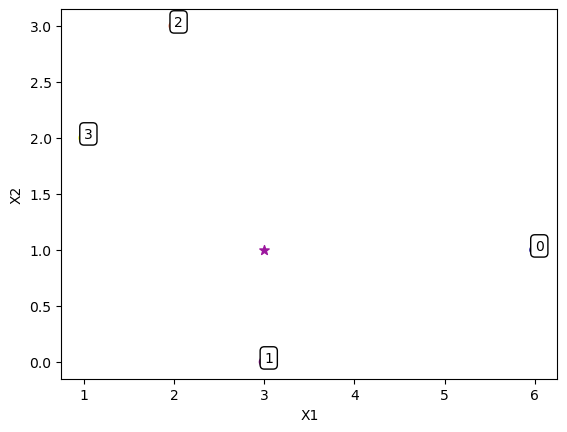

In [15]:
# Create a figure and axis for plotting
fig, ax = plt.subplots()

# Normalize color scale for cluster visualization
nm = Normalize(vmin=0, vmax=len(centers)-1)

# Scatter plot of the clustered data, colored by predicted cluster
ax.scatter(X[:, 0], X[:, 1],
           c=ms.predict(X), s=50, cmap='plasma', norm=nm)

# Plot the test point as a star, colored by its predicted cluster
ax.scatter(test_point[:,0], test_point[:,1], marker='*',
           c=ms.predict(test_point), s=50, cmap='plasma', norm=nm)

# Annotate each cluster center with its index number
for i in range(centers.shape[0]):
    ax.text(centers[i, 0], centers[i, 1], str(i), c='black',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

# Add axis labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')

